# Compare-Map Visualisations

This notebook loads a `metrics.jsonl` generated by `nas/compare-track.py`,
builds a table where rows are architectures and columns are maps, and then
plots the RMSEs so different planners can be compared at a glance.

Adjust the `RUN_DIR` value in the next cell if you want to point at a specific
run directory under `nas/compare-map/`. By default it selects the newest one.


In [66]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

try:
    BASE_OUTPUT_DIR = Path(__file__).resolve().parent
except NameError:
    BASE_OUTPUT_DIR = Path.cwd()


def latest_run_dir(base_dir: Path = BASE_OUTPUT_DIR) -> Path:
    candidates = sorted(
        [path for path in base_dir.glob("*/metrics.jsonl")],
        key=lambda p: p.stat().st_mtime,
    )
    if not candidates:
        raise FileNotFoundError(
            f"No metrics.jsonl files found under {base_dir}. Run nas/compare-track.py first."
        )
    return candidates[-1].parent

# RUN_DIR_OVERRIDE: Path | str | None = "compare_20260409T233950"  # e.g., "compare_20260410T133741"
RUN_DIR_OVERRIDE: Path | str | None = None


def resolve_run_dir() -> Path:
    if RUN_DIR_OVERRIDE:
        candidate = Path(RUN_DIR_OVERRIDE)
        if not candidate.is_absolute():
            candidate = BASE_OUTPUT_DIR / candidate
        if candidate.is_file():
            candidate = candidate.parent
        if not candidate.exists():
            raise FileNotFoundError(
                f"Override directory {candidate} was not found. Update RUN_DIR_OVERRIDE."
            )
        metrics_file = candidate / "metrics.jsonl"
        if not metrics_file.exists():
            raise FileNotFoundError(
                f"{metrics_file} was not found; choose a directory containing metrics.jsonl."
            )
        return candidate
    return latest_run_dir()

RUN_DIR = resolve_run_dir()
METRICS_FILE = RUN_DIR / "metrics.jsonl"
print(f"Using metrics from: {RUN_DIR}")

with METRICS_FILE.open("r", encoding="utf-8") as fh:
    METRIC_RECORDS = [json.loads(line) for line in fh if line.strip()]

if not METRIC_RECORDS:
    raise RuntimeError(f"{METRICS_FILE} is empty; rerun compare-track.")

rows: list[dict[str, object]] = []
for record in METRIC_RECORDS:
    map_name = record["map"]
    for run in record["runs"]:
        rows.append(
            {
                "map": map_name,
                "arch": run["label"],
                "rmse": run.get("rmse"),
            }
        )

df = pd.DataFrame(rows)
pivot = df.pivot_table(index="arch", columns="map", values="rmse")
pivot = pivot.sort_index()
print(f"Loaded RMSE table with shape {pivot.shape} (arches x maps).")


Using metrics from: /Users/zayahcortright/DAX.nosync/f1tenth_ng_zc/nas/compare-map/compare_20260413T185030
Loaded RMSE table with shape (8, 8) (arches x maps).


## RMSE table

Rows correspond to planner architectures; columns are maps. Each cell contains the
cross-track RMSE (in metres) reported by the simulator.


In [67]:
display(
    pivot.style
    .format("{:.4f}")
    .background_gradient(axis=0, cmap="YlGnBu")
    .set_properties(**{"text-align": "center"})
)


map,F1/Melbourne/Melbourne,F1/MexicoCity/MexicoCity,F1/Monza/Monza,F1/Nuerburgring/Nuerburgring,F1/Shanghai/Shanghai,F1/Silverstone/Silverstone,F1/Sochi/Sochi,F1/Spa/Spa
arch,,,,,,,,
arch1,0.1122,0.1348,0.0930,0.0950,0.1379,0.0929,0.1025,0.0928
arch2,0.1103,0.1245,0.0943,0.0996,0.1376,0.0946,0.0871,0.0919
arch3,0.1102,0.1481,0.0888,0.1083,0.1646,0.0941,0.1233,0.0818
arch4,0.1279,0.1478,0.0926,0.1442,0.1668,0.1224,0.1246,0.1089
arch5,0.1174,0.1403,0.0973,0.1406,0.1600,0.1296,0.1228,0.1183
arch6,0.1139,0.1365,0.0978,0.1388,0.1498,0.1318,0.1245,0.1180
arch7,0.1190,0.1417,0.0981,0.1425,0.1735,0.1282,0.1211,0.1155
arch8,0.0772,0.0979,0.0798,0.1099,0.1109,0.1139,0.1015,0.1019


## Connected RMSE comparison

A connected scatter plot (line plot with markers) makes it easy to see trends
per architecture: each line tracks an arch across maps, so you can spot where
one suddenly performs better or worse relative to the others. The x-axis
reflects each map explicitly so every point sits exactly on its label.


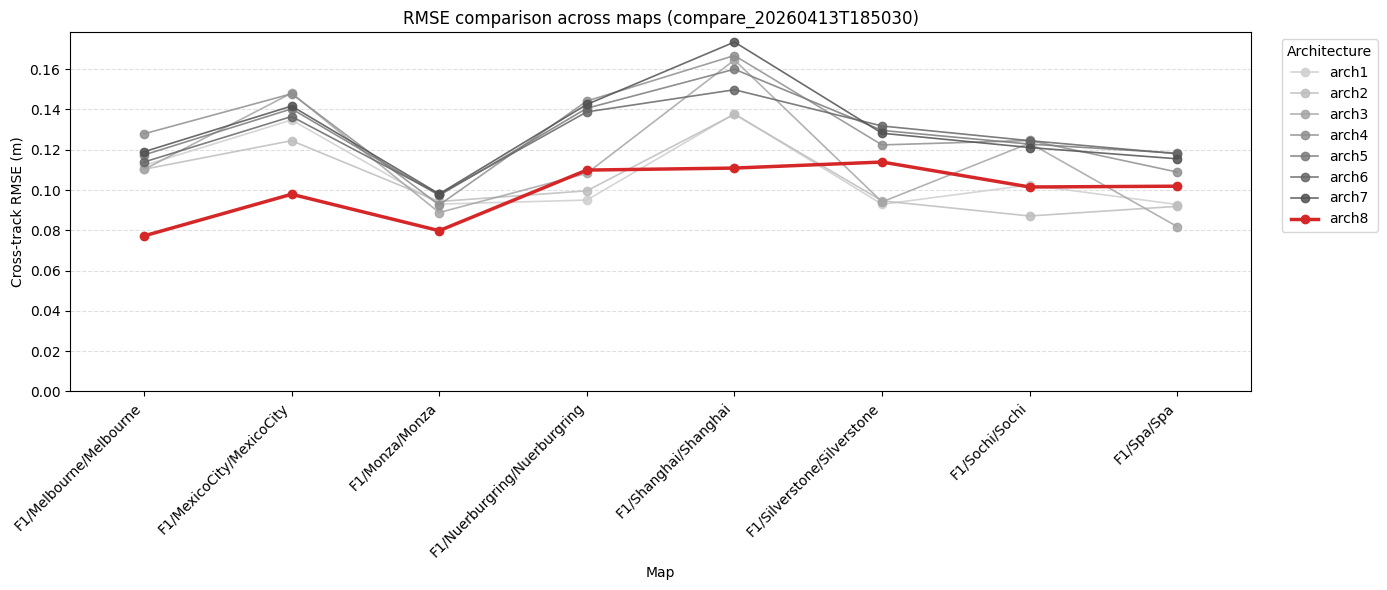

In [68]:
maps = list(pivot.columns)
x_positions = range(len(maps))
highlight_arch = "arch8"
has_highlight = highlight_arch in pivot.index
fig, ax = plt.subplots(figsize=(14, 6))
other_arches = [arch for arch in pivot.index if not (has_highlight and arch == highlight_arch)]
if other_arches:
    muted_scale = np.linspace(0.3, 0.75, len(other_arches))
    for scale, arch in zip(muted_scale, other_arches):
        color = plt.cm.Greys(scale)
        ax.plot(
            x_positions,
            pivot.loc[arch].values,
            marker="o",
            linewidth=1.2,
            color=color,
            alpha=0.85,
            label=arch,
        )
if has_highlight:
    ax.plot(
        x_positions,
        pivot.loc[highlight_arch].values,
        marker="o",
        linewidth=2.5,
        color="#d62728",
        label=highlight_arch,
    )
ax.set_xticks(list(x_positions))
ax.set_xticklabels(maps, rotation=45, ha="right")
ax.set_xlim(-0.5, len(maps) - 0.5)
ax.set_ylabel("Cross-track RMSE (m)")
ax.set_xlabel("Map")
ax.set_title(f"RMSE comparison across maps ({RUN_DIR.name})")
ax.set_ylim(bottom=0)
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
ax.legend(title="Architecture", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import base64
from pathlib import Path
from IPython.display import SVG, display

# ── Config ────────────────────────────────────────────────────────────────────

TRACE_FILE    = "compare_20260413T190736/F1_Melbourne_Melbourne_compare_20260413T190736.npz"
MAP_PNG       = Path("data/maps/F1/Melbourne/Melbourne_map.png")
SVG_OUTPUT    = 

# From Melbourne_map.yaml
RESOLUTION = 0.09009
ORIGIN     = [-81.75675943118459, -49.98378618463543]
IMG_W      = IMG_H = 2000

# ── Load ──────────────────────────────────────────────────────────────────────

if not TRACE_FILE.exists():
    raise FileNotFoundError(f"Trace archive not found: {TRACE_FILE}")
if not MAP_PNG.exists():
    raise FileNotFoundError(f"Map PNG not found: {MAP_PNG}")

raw = np.load(TRACE_FILE)
traces = [
    (key.removesuffix("_positions"), raw[key][:, :2].astype(float))
    for key in sorted(raw.files)
    if raw[key].ndim == 2 and raw[key].shape[1] >= 2
]
if not traces:
    raise RuntimeError(f"No usable position arrays in {TRACE_FILE}")

# ── Coordinate transform ──────────────────────────────────────────────────────

def world_to_px(xy: np.ndarray) -> np.ndarray:
    """World coords → PNG pixel coords (Y flipped, ROS map convention)."""
    out = np.empty_like(xy, dtype=float)
    out[:, 0] = (xy[:, 0] - ORIGIN[0]) / RESOLUTION
    out[:, 1] = IMG_H - (xy[:, 1] - ORIGIN[1]) / RESOLUTION
    return out

def polyline(xy: np.ndarray) -> str:
    px = world_to_px(xy)
    cmds = [f"M {px[0,0]:.2f} {px[0,1]:.2f}"]
    cmds += [f"L {x:.2f} {y:.2f}" for x, y in px[1:]]
    return " ".join(cmds)

# ── Colors ────────────────────────────────────────────────────────────────────

gray_labels = [label for label, _ in traces if label != "arch8"]
n = len(gray_labels)

def gray_hex(v: float) -> str:
    h = f"{int(v):02x}"
    return f"#{h}{h}{h}"

gray_map = {
    label: gray_hex(170 + i * (51 / max(n - 1, 1)))
    for i, label in enumerate(gray_labels)
}

# ── Build SVG ─────────────────────────────────────────────────────────────────

png_b64 = base64.b64encode(MAP_PNG.read_bytes()).decode()

parts = [
    f'<svg xmlns="http://www.w3.org/2000/svg" width="1200" height="1200" viewBox="0 0 {IMG_W} {IMG_H}">',
    f'<image href="data:image/png;base64,{png_b64}" x="0" y="0" width="{IMG_W}" height="{IMG_H}"/>',
]

for label, coords in traces:
    if label == "arch8":
        continue
    parts.append(
        f'<path d="{polyline(coords)}" stroke="{gray_map[label]}"'
        f' stroke-width="1" fill="none" stroke-linejoin="round" stroke-linecap="round"/>'
    )

for label, coords in traces:
    if label == "arch8":
        parts.append(
            f'<path d="{polyline(coords)}" stroke="#e81a1a"'
            f' stroke-width="1" fill="none" stroke-linejoin="round" stroke-linecap="round"/>'
        )

parts.append("</svg>")
svg_string = "\n".join(parts)

# ── Save & display ────────────────────────────────────────────────────────────

SVG_OUTPUT.write_text(svg_string, encoding="utf-8")
print(f"Saved → {SVG_OUTPUT}")
display(SVG(svg_string))

AttributeError: 'str' object has no attribute 'with_suffix'